# RecordDiff - Scaled Controlled MNAR Stress Test

## 1. Design rationale and grounding

**The data-generating process (DGP).** A latent severity $s_t$ follows a near–unit-root AR(1)
process; each variable's value is $x_t^{(v)}=\alpha_v s_t+\xi_t^{(v)}$; and the measurement
indicator is
$$m_t^{(v)}\sim\mathrm{Bernoulli}\big(\sigma(a_v s_t + b_{\text{scale}}\,b_v\,x_t^{(v)} + c_v)\big),$$
where $b_v\neq 0$ makes recording depend on the (unobserved) value itself — the defining
feature of **MNAR / non-ignorable** missingness (Rubin, 1976). Sweeping
$b_{\text{scale}}\in\{0,1,2,4\}$ moves the regime from ignorable (MAR-like) to strongly MNAR.

**Trigger lab (policy-sensitive label).** One variable ($v=V{-}1$) is independent of severity
and is measured *only when its own value spikes*. The patient label is "did a spike occur",
recoverable **only through the measurement pattern** — operationalising the clinical fact that
*measurement-pattern features alone* can be predictive (Shi et al., 2025; Yu et al., 2024;
Karami et al., 2024). As $V$ grows this becomes a genuine **needle-in-a-haystack** problem
(one informative variable among many), which is why $N$ must grow to keep detecting it.

**Generators (all share the identical fixed value base; only the mask differs).**

| Generator | Conditions mask on | Role |
|---|---|---|
| **Oracle joint** | true $(s,x)$ policy | upper bound *on mechanism fidelity* |
| **Learned policy (RecordDiff)** | $(s,x)$, *fit from data* | the **method** (Stage-1 surrogate) |
| MAR only | $(s,t)$ only | ablation: severity-driven, value-blind |
| Independent mask | marginal $(t,v)$ rates | ablation: unconditional profile only |
| Mask replay | whole real trajectories | ablation: temporal structure, decoupled from $x$ |

**Diffusion connection.** In full RecordDiff the value model is a conditional DDPM trained on
*observed coordinates only* (Ho et al., 2020; Sohl-Dickstein et al., 2015; Tashiro et al.,
2021). This stress test deliberately fixes the value base so that *every* downstream
difference is attributable to the **mask policy** — the cleanest possible isolation of the
proposal's central claim that *misspecifying the missingness mechanism, not model capacity,
is what displaces downstream conclusions.*

**Metrics.** (a) mask–value dependence AUC of a probe $m\!\sim\!(s,x)$; (b) mechanism recovery
$\frac1V\sum_v|\hat b_v-b_{\text{scale}}b_v|$; (c) Train-on-Synthetic Test-on-Real (TSTR)
AUROC with **mask-only** features (Esteban et al.-style synthetic-data utility); (d) the paired
contrast $\Delta_{\text{TSTR}}$.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time
np.seterr(all="ignore")
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.0.2 | pandas 2.2.2


## 2. Core engine (DGP, generators, metrics, statistics)

Validated, vectorised NumPy/scikit-learn. Run this cell once; everything below uses it.

In [ ]:
import time
import numpy as np
from scipy.special import expit
from scipy.stats import wilcoxon
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

RHO = 0.95          # near-unit-root AR(1) severity
SIGMA_S = 1.0
C_LINK = -1.0       # intercept for severity-linked measurement policy
SPIKE_P = 0.03      # per-(patient,time) spike probability in a trigger lab
SPIKE_MAG = 2.0
TRIG_ALPHA = 0.0    # trigger lab independent of severity
TRIG_SIGMA = 2.0
TRIG_A = 0.0        # trigger lab not severity-ordered
TRIG_B = 0.6        # value-driven ordering coefficient (MNAR)
TRIG_C = -5.0       # rarely measured unless value is large

# Variable coefficients (stable across N for a given (V, seed) so that the N-sweep keeps an identical DGP and only changes sample size)
def make_coeffs(V, n_trigger, coeff_seed):
    rng = np.random.default_rng(coeff_seed)
    n_link = V - n_trigger
    assert n_link >= 1, "need at least one severity-linked variable"
    alpha = np.empty(V, dtype=np.float64)
    sigma = np.empty(V, dtype=np.float64)
    a = np.empty(V, dtype=np.float64)
    b = np.empty(V, dtype=np.float64)
    c = np.empty(V, dtype=np.float64)
    # severity-linked variables
    alpha[:n_link] = rng.uniform(0.6, 1.4, size=n_link)
    sigma[:n_link] = rng.uniform(0.9, 1.3, size=n_link)
    a[:n_link] = rng.uniform(0.3, 0.9, size=n_link)
    b[:n_link] = rng.uniform(0.2, 0.8, size=n_link)
    c[:n_link] = C_LINK
    # trigger labs
    alpha[n_link:] = TRIG_ALPHA
    sigma[n_link:] = TRIG_SIGMA
    a[n_link:] = TRIG_A
    b[n_link:] = TRIG_B
    c[n_link:] = TRIG_C
    link_idx = np.arange(n_link)
    trig_idx = np.arange(n_link, V)
    return dict(alpha=alpha, sigma=sigma, a=a, b=b, c=c,
                link_idx=link_idx, trig_idx=trig_idx, n_link=n_link)

# Simulate the shared base (s, x, spike-label). Mask is added per generator
def simulate_base(N, T, V, coeffs, seed):
    rng = np.random.default_rng(seed)
    alpha = coeffs["alpha"]; sigma = coeffs["sigma"]; trig_idx = coeffs["trig_idx"]
    s = np.empty((N, T), dtype=np.float32)
    eta = rng.normal(0.0, SIGMA_S, size=(N, T)).astype(np.float32)
    s[:, 0] = eta[:, 0]
    for t in range(1, T):
        s[:, t] = RHO * s[:, t - 1] + eta[:, t]
    xi = rng.normal(0.0, 1.0, size=(N, T, V)).astype(np.float32) * sigma.astype(np.float32)[None, None, :]
    x = alpha.astype(np.float32)[None, None, :] * s[:, :, None] + xi
    spikes = (rng.random((N, T, len(trig_idx))) < SPIKE_P)
    x[:, :, trig_idx] += (SPIKE_MAG * spikes).astype(np.float32)
    label = spikes.any(axis=(1, 2)).astype(np.int8)
    return s, x, label


def oracle_mask(s, x, coeffs, b_scale, seed):
    rng = np.random.default_rng(seed)
    a = coeffs["a"].astype(np.float32); b = coeffs["b"].astype(np.float32); c = coeffs["c"].astype(np.float32)
    logits = (a[None, None, :] * s[:, :, None]
              + (b_scale * b)[None, None, :] * x
              + c[None, None, :])
    p = expit(logits)
    return (rng.random(p.shape) < p).astype(np.int8)

# Per-patient mask features for TSTR (count, rate, first/last obs time per var)
def mask_features(m):
    N, T, V = m.shape
    count = m.sum(axis=1).astype(np.float32)
    rate = count / T
    tgrid = np.arange(T, dtype=np.float32)[None, :, None]
    obs = m.astype(bool)
    first = np.where(obs.any(axis=1),
                     np.argmax(obs, axis=1).astype(np.float32),
                     np.float32(T)) / T
    rev = obs[:, ::-1, :]
    last_idx = np.where(obs.any(axis=1),
                        (T - 1 - np.argmax(rev, axis=1)).astype(np.float32),
                        np.float32(-1.0))
    last = (last_idx + 1.0) / T
    return np.concatenate([count, rate, first, last], axis=1)


def _subsample_rows(n, cap, rng):
    if n <= cap:
        return slice(None)
    return rng.choice(n, size=cap, replace=False)

# Generators: each returns a mask m for the fixed base (s, x)
# real_* arguments provide the "held-out real cohort" used to fit baselines
class Generators:
    def __init__(self, coeffs, b_scale):
        self.coeffs = coeffs
        self.b_scale = b_scale

    def oracle(self, s, x, seed):
        return oracle_mask(s, x, self.coeffs, self.b_scale, seed)

    def learned(self, s, x, real_s, real_x, real_m, seed, row_cap=200_000):
        rng = np.random.default_rng(seed)
        N, T, V = x.shape
        rs = real_s.reshape(-1)
        out_logits = np.empty((N * T, V), dtype=np.float32)
        Xflat = x.reshape(-1, V)
        sflat = s.reshape(-1)
        for v in range(V):
            yv = real_m[:, :, v].reshape(-1)
            Xv = np.column_stack([rs, real_x[:, :, v].reshape(-1)])
            sub = _subsample_rows(Xv.shape[0], row_cap, rng)
            yv_s = yv[sub]
            if yv_s.min() == yv_s.max():
                p_const = float(yv_s.mean())
                out_logits[:, v] = np.log((p_const + 1e-6) / (1 - p_const + 1e-6))
                continue
            clf = LogisticRegression(max_iter=200, C=1.0)
            clf.fit(Xv[sub], yv_s)
            feat = np.column_stack([sflat, Xflat[:, v]])
            out_logits[:, v] = clf.decision_function(feat)
        p = expit(out_logits).reshape(N, T, V)
        return (rng.random(p.shape) < p).astype(np.int8)

    def independent(self, s, x, real_m, seed):
        rng = np.random.default_rng(seed)
        p = real_m.mean(axis=0)[None, :, :]
        N = x.shape[0]
        return (rng.random((N,) + p.shape[1:]) < p).astype(np.int8)

    def mar_only(self, s, x, real_s, real_m, seed, row_cap=200_000):
        rng = np.random.default_rng(seed)
        N, T, V = x.shape
        tnorm_real = (np.tile(np.arange(T), (real_s.shape[0], 1)).astype(np.float32) / T).reshape(-1)
        rs = real_s.reshape(-1)
        tnorm = (np.tile(np.arange(T), (N, 1)).astype(np.float32) / T).reshape(-1)
        sflat = s.reshape(-1)
        out_logits = np.empty((N * T, V), dtype=np.float32)
        for v in range(V):
            yv = real_m[:, :, v].reshape(-1)
            Xv = np.column_stack([rs, tnorm_real])
            sub = _subsample_rows(Xv.shape[0], row_cap, rng)
            yv_s = yv[sub]
            if yv_s.min() == yv_s.max():
                p_const = float(yv_s.mean())
                out_logits[:, v] = np.log((p_const + 1e-6) / (1 - p_const + 1e-6))
                continue
            clf = LogisticRegression(max_iter=200, C=1.0)
            clf.fit(Xv[sub], yv_s)
            out_logits[:, v] = clf.decision_function(np.column_stack([sflat, tnorm]))
        p = expit(out_logits).reshape(N, T, V)
        return (rng.random(p.shape) < p).astype(np.int8)

    def mask_replay(self, s, x, real_m, seed):
        rng = np.random.default_rng(seed)
        N = x.shape[0]
        idx = rng.integers(0, real_m.shape[0], size=N)
        return real_m[idx].copy()

# Fidelity metrics
def fidelity_probe(m, s, x, link_idx, true_b, b_scale,
                   max_vars=20, row_cap=80_000, seed=0):

    rng = np.random.default_rng(seed)
    vars_used = (link_idx if len(link_idx) <= max_vars
                 else rng.choice(link_idx, max_vars, replace=False))
    sflat = s.reshape(-1)
    aucs, errs = [], []
    for v in vars_used:
        target = b_scale * true_b[v]
        yv = m[:, :, v].reshape(-1)
        Xv = np.column_stack([sflat, x[:, :, v].reshape(-1)])
        sub = _subsample_rows(Xv.shape[0], row_cap, rng)
        ys = yv[sub]; Xs = Xv[sub]
        if ys.min() == ys.max():
            aucs.append(0.5); errs.append(abs(0.0 - target)); continue
        clf = LogisticRegression(max_iter=200, C=1.0)
        clf.fit(Xs, ys)
        aucs.append(roc_auc_score(ys, clf.decision_function(Xs)))
        errs.append(abs(clf.coef_[0, 1] - target))
    return float(np.mean(aucs)), float(np.mean(errs))


def tstr_auroc(train_mask, train_label, test_mask, test_label, C=0.5):
    Xtr = mask_features(train_mask)
    Xte = mask_features(test_mask)
    sc = StandardScaler().fit(Xtr)
    Xtr = sc.transform(Xtr); Xte = sc.transform(Xte)
    if len(np.unique(train_label)) < 2:
        return 0.5
    clf = LogisticRegression(max_iter=500, C=C)
    clf.fit(Xtr, train_label)
    return float(roc_auc_score(test_label, clf.decision_function(Xte)))

METHODS = ["oracle", "learned", "independent", "mar_only", "mask_replay"]
MISMATCHED = ["independent", "mar_only", "mask_replay"]


def run_config(V, N_train, T, b_scale, seed, n_trigger=1,
               coeff_seed_base=10_000, fit_diag=True):
    coeffs = make_coeffs(V, n_trigger, coeff_seed_base + V)
    link_idx = coeffs["link_idx"]; b_true = coeffs["b"]
    N_test = max(1000, N_train // 2)

    s_base, x_base, lab_base = simulate_base(N_train, T, V, coeffs, seed=1000 + seed)
    s_real, x_real, lab_real = simulate_base(N_train, T, V, coeffs, seed=5000 + seed)
    s_test, x_test, lab_test = simulate_base(N_test, T, V, coeffs, seed=9000 + seed)

    real_m = oracle_mask(s_real, x_real, coeffs, b_scale, seed=3000 + seed)
    test_m = oracle_mask(s_test, x_test, coeffs, b_scale, seed=7000 + seed)

    gen = Generators(coeffs, b_scale)
    masks = {}
    masks["oracle"] = gen.oracle(s_base, x_base, seed=2000 + seed)
    masks["learned"] = gen.learned(s_base, x_base, s_real, x_real, real_m, seed=2100 + seed, row_cap=60_000)
    masks["independent"] = gen.independent(s_base, x_base, real_m, seed=2200 + seed)
    masks["mar_only"] = gen.mar_only(s_base, x_base, s_real, real_m, seed=2300 + seed, row_cap=60_000)
    masks["mask_replay"] = gen.mask_replay(s_base, x_base, real_m, seed=2400 + seed)

    out = {"V": V, "N_train": N_train, "T": T, "b_scale": b_scale, "seed": seed}
    for meth, m in masks.items():
        if fit_diag:
            dep, mech = fidelity_probe(m, s_base, x_base, link_idx, b_true, b_scale, seed=seed)
            out[f"dep_auc::{meth}"] = dep
            out[f"mech_err::{meth}"] = mech
        out[f"tstr::{meth}"] = tstr_auroc(m, lab_base, test_m, lab_test)
    return out

# Statistical utilities
def bootstrap_ci(values, n_boot=20_000, ci=0.95, seed=0):
    v = np.asarray(values, float)
    if len(v) == 0:
        return (np.nan, np.nan, np.nan)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(v), size=(n_boot, len(v)))
    means = v[idx].mean(axis=1)
    lo = np.percentile(means, 100 * (1 - ci) / 2)
    hi = np.percentile(means, 100 * (1 + ci) / 2)
    return float(v.mean()), float(lo), float(hi)


def signflip_test(deltas, n_perm=200_000, seed=0):
    d = np.asarray(deltas, float)
    obs = d.mean()
    rng = np.random.default_rng(seed)
    signs = rng.integers(0, 2, size=(n_perm, len(d))) * 2 - 1
    perm = (signs * np.abs(d)).mean(axis=1)
    return float((1 + np.sum(perm >= obs)) / (n_perm + 1))


def wilcoxon_greater(deltas):
    d = np.asarray(deltas, float)
    if np.allclose(d, 0):
        return 1.0
    try:
        return float(wilcoxon(d, alternative="greater", zero_method="wilcox").pvalue)
    except ValueError:
        return 1.0


def bh_fdr(pvals):
    p = np.asarray(pvals, float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order] * n / (np.arange(n) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    q = np.empty(n)
    q[order] = np.clip(ranked, 0, 1)
    return q


def wilcoxon_power_floor(n_seeds, n_tests):
    p_floor = 0.5 ** n_seeds
    q_floor_bh = min(1.0, p_floor * n_tests)
    return p_floor, q_floor_bh

## 3. Configuration

`QUICK` (default) reproduces every figure at reduced scale/seeds in a few minutes.
`FULL` runs the realistic-scale study. Scaling sweeps use `fit_diag=False` (TSTR only) for
speed; the anchor sweep computes the full fidelity diagnostics.

In [ ]:
PRESET = "FULL"        # "QUICK"   |   "FULL"
CHECKPOINT = True      # set True to cache each sweep to disk

if PRESET == "FULL":
    SEEDS_ANCHOR = list(range(20)); SEEDS_SCALE = list(range(20)); SEEDS_GRID = list(range(8))
    ANCHOR_V, ANCHOR_N = 32, 16_000
    N_GRID = [4_000, 8_000, 16_000, 32_000, 64_000]
    V_GRID = [6, 16, 32, 64, 128]
    GRID_V, GRID_N = [16, 32, 64, 128], [8_000, 16_000, 32_000]
else:
    SEEDS_ANCHOR = list(range(8)); SEEDS_SCALE = list(range(6)); SEEDS_GRID = list(range(4))
    ANCHOR_V, ANCHOR_N = 24, 8_000
    N_GRID = [4_000, 8_000, 16_000, 32_000]
    V_GRID = [8, 16, 32, 64]
    GRID_V, GRID_N = [16, 32, 64], [8_000, 16_000]

B_SWEEP = [0, 1, 2, 4]
_pf, _qf = wilcoxon_power_floor(len(SEEDS_ANCHOR), len(B_SWEEP))
print(f"PRESET={PRESET} | anchor V={ANCHOR_V} N={ANCHOR_N} | "
      f"N_GRID={N_GRID} | V_GRID={V_GRID} | seeds(anchor)={len(SEEDS_ANCHOR)}")
print(f"stat. resolution: with {len(SEEDS_ANCHOR)} seeds the one-sided Wilcoxon floor is "
      f"p={_pf:.4g}; best attainable BH-q across {len(B_SWEEP)} levels ~= {_qf:.4g}")

PRESET=FULL | anchor V=32 N=16000 | N_GRID=[4000, 8000, 16000, 32000, 64000] | V_GRID=[6, 16, 32, 64, 128] | seeds(anchor)=20
stat. resolution: with 20 seeds the one-sided Wilcoxon floor is p=9.537e-07; best attainable BH-q across 4 levels ~= 3.815e-06


## 4. Sweep / plotting / statistics pipeline

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k): return x

import os, pickle


# optional checkpointing
CHECKPOINT_DIR = os.environ.get("RD_CKPT_DIR", ".")
CHECKPOINT = globals().get("CHECKPOINT", False)


def run_or_load(name, configs, seeds, fit_diag=True, desc="sweep"):
    path = os.path.join(CHECKPOINT_DIR, f"{name}.pkl")
    if CHECKPOINT and os.path.exists(path):
        with open(path, "rb") as fh:
            df, tim = pickle.load(fh)
        print(f"[checkpoint] loaded '{name}' ({len(df)} rows) from {path}")
        return df, tim
    df, tim = run_sweep(configs, seeds, fit_diag=fit_diag, desc=desc)
    if CHECKPOINT:
        with open(path, "wb") as fh:
            pickle.dump((df, tim), fh)
        print(f"[checkpoint] saved '{name}' -> {path}")
    return df, tim

METHOD_STYLE = {
    "oracle":      dict(label="Oracle joint",        color="#1f5fae", marker="o"),
    "learned":     dict(label="Learned policy (RecordDiff)", color="#8c1d40", marker="D"),
    "independent": dict(label="Indep. mask",         color="#e08a1e", marker="s"),
    "mar_only":    dict(label="MAR only",            color="#2e8b57", marker="^"),
    "mask_replay": dict(label="Mask replay",         color="#7a4fb5", marker="v"),
}
PLOT_ORDER = ["oracle", "learned", "mar_only", "independent", "mask_replay"]


def _set_style():
    plt.rcParams.update({
        "figure.dpi": 120, "savefig.dpi": 150, "font.size": 10,
        "axes.titlesize": 11, "axes.titleweight": "bold",
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
    })


# sweep runners
def run_sweep(configs, seeds, fit_diag=True, desc="sweep"):
    """configs: list of dicts with V,N_train,T,b_scale. Returns long DataFrame."""
    rows, timings = [], []
    for cfg in tqdm(configs, desc=desc):
        for s in seeds:
            t0 = time.time()
            r = run_config(V=cfg["V"], N_train=cfg["N_train"], T=cfg.get("T", 24),
                           b_scale=cfg["b_scale"], seed=s, fit_diag=fit_diag)
            dt = time.time() - t0
            r["wall_s"] = dt
            rows.append(r)
            timings.append(dict(V=cfg["V"], N_train=cfg["N_train"],
                                b_scale=cfg["b_scale"], seed=s, wall_s=dt))
    return pd.DataFrame(rows), pd.DataFrame(timings)


def melt_metric(df, metric):
    """Wide per-method cols (metric::method) -> long with method column."""
    cols = [c for c in df.columns if c.startswith(metric + "::")]
    keep = ["V", "N_train", "T", "b_scale", "seed"]
    long = df[keep + cols].melt(id_vars=keep, value_vars=cols,
                                var_name="method", value_name=metric)
    long["method"] = long["method"].str.split("::").str[-1]
    return long


def agg_ci(long, metric, group_cols, n_boot=20_000):
    out = []
    for key, g in long.groupby(group_cols + ["method"]):
        m, lo, hi = bootstrap_ci(g[metric].values, n_boot=n_boot)
        rec = dict(zip(group_cols + ["method"], key if isinstance(key, tuple) else (key,)))
        rec.update(mean=m, lo=lo, hi=hi)
        out.append(rec)
    return pd.DataFrame(out)


# four-panel anchor figure
def plot_anchor(df, V, N, title=None):
    _set_style()
    fig, ax = plt.subplots(2, 2, figsize=(11, 8))
    panels = [("dep_auc", "Mask dependence AUC", "Measurement dependence fidelity", 0.5),
              ("tstr", "TSTR AUROC", "Train-on-synthetic, test-on-real", 0.5),
              ("mech_err", r"$|\hat b - b|$", "Mechanism recovery error", None),
              (None, None, None, None)]
    for axi, (metric, ylab, ttl, chance) in zip(ax.flat[:3], panels[:3]):
        long = melt_metric(df, metric)
        a = agg_ci(long, metric, ["b_scale"])
        for meth in PLOT_ORDER:
            d = a[a.method == meth].sort_values("b_scale")
            st = METHOD_STYLE[meth]
            axi.plot(d.b_scale, d["mean"], marker=st["marker"], color=st["color"],
                     label=st["label"], lw=2, ms=5)
            axi.fill_between(d.b_scale, d.lo, d.hi, color=st["color"], alpha=0.15)
        if chance is not None:
            axi.axhline(chance, ls="--", color="gray", lw=1)
        axi.set_xlabel("b scale"); axi.set_ylabel(ylab); axi.set_title(ttl)

    axd = ax.flat[3]
    tl = melt_metric(df, "tstr")
    wide = tl.pivot_table(index=["b_scale", "seed"], columns="method", values="tstr").reset_index()
    for ref, col, lab in [("oracle", "#1f5fae", r"oracle$-$indep"),
                          ("learned", "#8c1d40", r"learned$-$indep")]:
        wide[f"d_{ref}"] = wide[ref] - wide["independent"]
        rows = []
        for bs, g in wide.groupby("b_scale"):
            m, lo, hi = bootstrap_ci(g[f"d_{ref}"].values)
            rows.append((bs, m, lo, hi))
        rr = pd.DataFrame(rows, columns=["b_scale", "m", "lo", "hi"]).sort_values("b_scale")
        axd.plot(rr.b_scale, rr.m, marker="o", color=col, lw=2, label=lab)
        axd.fill_between(rr.b_scale, rr.lo, rr.hi, color=col, alpha=0.15)
    axd.axhline(0, ls="--", color="gray", lw=1)
    axd.set_xlabel("b scale"); axd.set_ylabel(r"$\Delta$TSTR AUROC")
    axd.set_title("Conclusion sensitivity"); axd.legend(loc="upper left", fontsize=8)

    h, l = ax.flat[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.02), fontsize=9)
    fig.suptitle(title or f"Scaled synthetic fidelity evaluation  (V={V}, N_train={N})",
                 fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0.03, 1, 0.97])
    return fig

# stats table for paired sensitivity
def sensitivity_table(df, ref="oracle", base="independent", n_perm=200_000):
    tl = melt_metric(df, "tstr")
    wide = tl.pivot_table(index=["b_scale", "seed"], columns="method", values="tstr").reset_index()
    wide["delta"] = wide[ref] - wide[base]
    bvals = sorted(wide.b_scale.unique())
    rows, pw, ps = [], [], []
    for bs in bvals:
        d = wide[wide.b_scale == bs]["delta"].values
        m, lo, hi = bootstrap_ci(d)
        pwil = wilcoxon_greater(d); psgn = signflip_test(d, n_perm=n_perm)
        pw.append(pwil); ps.append(psgn)
        rows.append(dict(b_scale=bs, delta=m, ci_lo=lo, ci_hi=hi,
                         p_wilcoxon=pwil, p_signflip=psgn))
    qw = bh_fdr(pw); qs = bh_fdr(ps)
    tab = pd.DataFrame(rows)
    tab["q_wilcoxon_BH"] = qw; tab["q_signflip_BH"] = qs
    return tab[["b_scale", "delta", "ci_lo", "ci_hi",
                "p_wilcoxon", "q_wilcoxon_BH", "q_signflip_BH"]]

# N / V scaling plots
def plot_scaling(df, axis, fixed_label, strong_b=4):
    """axis in {'N_train','V'}: 3-panel scaling figure at strong MNAR."""
    _set_style()
    d = df[df.b_scale == strong_b]
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
    xname = axis

    tl = melt_metric(d, "tstr"); a = agg_ci(tl, "tstr", [xname])
    for meth in PLOT_ORDER:
        g = a[a.method == meth].sort_values(xname); st = METHOD_STYLE[meth]
        ax[0].plot(g[xname], g["mean"], marker=st["marker"], color=st["color"], label=st["label"], lw=2)
        ax[0].fill_between(g[xname], g.lo, g.hi, color=st["color"], alpha=0.15)
    ax[0].axhline(0.5, ls="--", color="gray", lw=1)
    ax[0].set_xlabel(xname); ax[0].set_ylabel("TSTR AUROC")
    ax[0].set_title(f"TSTR vs {xname}  (b={strong_b})"); ax[0].legend(fontsize=8)
    if axis == "N_train": ax[0].set_xscale("log")

    tlw = tl.pivot_table(index=[xname, "seed"], columns="method", values="tstr").reset_index()
    tlw["delta"] = tlw["oracle"] - tlw["independent"]
    rows = []
    for xv, g in tlw.groupby(xname):
        m, lo, hi = bootstrap_ci(g["delta"].values)
        rows.append((xv, m, lo, hi, (hi - lo) / 2))
    rr = pd.DataFrame(rows, columns=[xname, "m", "lo", "hi", "halfwidth"]).sort_values(xname)
    ax[1].plot(rr[xname], rr.m, marker="o", color="#1f5fae", lw=2, label=r"$\Delta$TSTR (oracle$-$indep)")
    ax[1].fill_between(rr[xname], rr.lo, rr.hi, color="#1f5fae", alpha=0.15)
    ax2 = ax[1].twinx()
    ax2.plot(rr[xname], rr.halfwidth, marker="x", color="#b03060", ls=":", label="between-seed CI half-width")
    ax2.set_ylabel("CI half-width (between-seed)", color="#b03060"); ax2.grid(False)
    ax[1].axhline(0, ls="--", color="gray", lw=1)
    ax[1].set_xlabel(xname); ax[1].set_ylabel(r"$\Delta$TSTR")
    ax[1].set_title("Effect size & precision"); ax[1].legend(fontsize=8, loc="center right")
    if axis == "N_train": ax[1].set_xscale("log")

    tlw["gap"] = tlw["oracle"] - tlw["learned"]
    rows = []
    for xv, g in tlw.groupby(xname):
        m, lo, hi = bootstrap_ci(np.abs(g["gap"].values))
        rows.append((xv, m, lo, hi))
    gg = pd.DataFrame(rows, columns=[xname, "m", "lo", "hi"]).sort_values(xname)
    ax[2].plot(gg[xname], gg.m, marker="D", color="#8c1d40", lw=2)
    ax[2].fill_between(gg[xname], gg.lo, gg.hi, color="#8c1d40", alpha=0.15)
    ax[2].axhline(0, ls="--", color="gray", lw=1)
    ax[2].set_xlabel(xname); ax[2].set_ylabel(r"$|$TSTR$_{oracle}-$TSTR$_{learned}|$")
    ax[2].set_title("Learned-policy gap to oracle")
    if axis == "N_train": ax[2].set_xscale("log")
    fig.suptitle(f"Scaling along {xname}  ({fixed_label})", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

# pass criteria
def check_criteria(anchor_df, n_df=None, v_df=None, strong_b=4, n_seeds=None,
                   alpha=0.05, n_perm=50_000):

    a = anchor_df
    def mean_at(df, metric, meth, bs):
        sub = df[df.b_scale == bs]
        return sub[f"{metric}::{meth}"].mean()

    bvals = sorted(a.b_scale.unique())
    if n_seeds is None:
        n_seeds = int(a[a.b_scale == strong_b]["seed"].nunique())
    p_floor, q_floor = wilcoxon_power_floor(n_seeds, len(bvals))

    tl = melt_metric(a, "tstr")
    wide = tl.pivot_table(index=["b_scale", "seed"], columns="method", values="tstr").reset_index()
    ds = wide[wide.b_scale == strong_b]
    deltas = (ds["oracle"] - ds["independent"]).values
    gap, lo_b, hi_b = bootstrap_ci(deltas)

    tab = sensitivity_table(a, ref="oracle", base="independent", n_perm=n_perm)
    row = tab[tab.b_scale == strong_b].iloc[0]
    q_wil = float(row["q_wilcoxon_BH"]); q_sf = float(row["q_signflip_BH"])

    crit = {}
    crit["T1_oracle dep-AUC >= 0.75 @strong"] = dict(
        passed=mean_at(a, "dep_auc", "oracle", strong_b) >= 0.75,
        value=round(float(mean_at(a, "dep_auc", "oracle", strong_b)), 4), tier="primary")
    crit["T2b_oracle-indep delta CI excludes 0 @strong"] = dict(
        passed=lo_b > 0, value=(round(float(lo_b), 4), round(float(hi_b), 4)), tier="primary")
    crit["T2q_oracle-indep FDR q < 0.05 @strong"] = dict(
        passed=q_wil < alpha, value=round(q_wil, 4), tier="primary",
        note=f"q_signflip={q_sf:.4f}")
    gap0 = mean_at(a, "tstr", "oracle", 0) - mean_at(a, "tstr", "independent", 0)
    crit["T3_gap <= 0.02 @b=0 (neg control)"] = dict(
        passed=abs(gap0) <= 0.02, value=round(float(gap0), 4), tier="primary")
    lgap = abs(mean_at(a, "tstr", "oracle", strong_b) - mean_at(a, "tstr", "learned", strong_b))
    crit["T4_learned within 0.02 of oracle @strong"] = dict(
        passed=lgap <= 0.02, value=round(float(lgap), 4), tier="primary")
    le = mean_at(a, "mech_err", "learned", strong_b)
    ie = mean_at(a, "mech_err", "independent", strong_b)
    crit["T5_learned mech_err < 0.25*indep @strong"] = dict(
        passed=le < 0.25 * ie, value=(round(float(le), 4), round(float(ie), 4)), tier="primary")

    crit["T2_oracle-indep TSTR gap >= 0.05 @strong"] = dict(
        passed=gap >= 0.05, value=round(float(gap), 4), tier="advisory")

    primary_pass = all(v["passed"] for v in crit.values() if v["tier"] == "primary")

    diagnosis = None
    if not crit["T2_oracle-indep TSTR gap >= 0.05 @strong"]["passed"]:
        sig = crit["T2q_oracle-indep FDR q < 0.05 @strong"]["passed"]
        ci_ok = crit["T2b_oracle-indep delta CI excludes 0 @strong"]["passed"]
        if sig and ci_ok:
            diagnosis = ("at-threshold",
                f"the effect IS FDR-significant (q={q_wil:.4g}) and its CI excludes 0, but the "
                f"point estimate ({gap:.4f}) is just under the absolute 0.05 bar. This is a "
                f"threshold-calibration issue, not a power or method failure; T2b/T2q (primary) "
                f"carry the claim. More seeds will converge the estimate, not lift it over 0.05.")
        elif p_floor >= alpha:
            diagnosis = ("seed-limited",
                f"with {n_seeds} seeds the one-sided Wilcoxon p-floor is {p_floor:.4g} >= {alpha}: "
                f"even an all-positive result cannot reach significance, regardless of effect "
                f"size. Add seeds (e.g. FULL) before reading T2.")
        else:
            diagnosis = ("underpowered-or-absent",
                f"significance is reachable at {n_seeds} seeds (p-floor={p_floor:.4g}) but was not "
                f"attained (q={q_wil:.4g}) and the gap ({gap:.4f}) is below 0.05; increase scale "
                f"and/or seeds, or inspect whether the effect is genuinely absent here.")

    summary = dict(primary_pass=primary_pass, n_seeds=n_seeds, alpha=alpha,
                   p_floor=p_floor, q_floor=q_floor,
                   q_oracle_indep_wilcoxon=q_wil, q_oracle_indep_signflip=q_sf,
                   t2_diagnosis=diagnosis)
    return crit, summary


def plot_grid_heatmap(df, strong_b=4):
    """Heatmap of mean delta-TSTR (oracle-indep) over V x N at strong MNAR."""
    _set_style()
    d = df[df.b_scale == strong_b]
    tl = melt_metric(d, "tstr")
    wide = tl.pivot_table(index=["V", "N_train", "seed"], columns="method",
                          values="tstr").reset_index()
    wide["delta"] = wide["oracle"] - wide["independent"]
    grid = wide.groupby(["V", "N_train"])["delta"].mean().reset_index()
    piv = grid.pivot(index="V", columns="N_train", values="delta").sort_index(ascending=False)
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(piv.values, aspect="auto", cmap="RdPu")
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
    ax.set_xlabel("N_train"); ax.set_ylabel("V (variables)")
    ax.set_title(rf"Effect size $\Delta$TSTR (oracle$-$indep) at b={strong_b}")
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                        color="white" if v > np.nanmax(piv.values) * 0.6 else "black", fontsize=9)
    fig.colorbar(im, ax=ax, label=r"$\Delta$TSTR")
    ax.grid(False); fig.tight_layout()
    by_v = piv.mean(axis=1).sort_index()
    by_n = piv.mean(axis=0).sort_index()
    print("marginal effect vs V (avg over N):")
    for v_, e_ in by_v.items():
        print(f"    V={int(v_):>4}  mean dTSTR={e_:.4f}")
    print("marginal effect vs N (avg over V):")
    for n_, e_ in by_n.items():
        print(f"    N={int(n_):>6}  mean dTSTR={e_:.4f}")
    return fig


def plot_runtime(timings):
    _set_style()
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    g = timings.groupby("N_train")["wall_s"].mean().reset_index()
    ax[0].plot(g.N_train, g.wall_s, "o-", color="#1f5fae")
    ax[0].set_xscale("log"); ax[0].set_xlabel("N_train"); ax[0].set_ylabel("wall time / config (s)")
    ax[0].set_title("Runtime vs records")
    g2 = timings.groupby("V")["wall_s"].mean().reset_index()
    ax[1].plot(g2.V, g2.wall_s, "D-", color="#8c1d40")
    ax[1].set_xlabel("V (variables)"); ax[1].set_ylabel("wall time / config (s)")
    ax[1].set_title("Runtime vs variables")
    fig.tight_layout()
    return fig

### 4.1 Quick self-test

In [ ]:
r = run_config(V=12, N_train=2000, T=24, b_scale=4, seed=0)
print(f"TSTR  oracle={r['tstr::oracle']:.3f}  "
      f"learned={r['tstr::learned']:.3f}  "
      f"indep={r['tstr::independent']:.3f}")
print(f"mech  oracle={r['mech_err::oracle']:.3f}  "
      f"learned={r['mech_err::learned']:.3f}  "
      f"indep={r['mech_err::independent']:.3f}")

TSTR  oracle=0.554  learned=0.561  indep=0.507
mech  oracle=0.018  learned=0.030  indep=1.953


## 5. Experiment A: Anchor sweep at scale

In [ ]:
anchor_cfgs = [dict(V=ANCHOR_V, N_train=ANCHOR_N, b_scale=b) for b in B_SWEEP]
anchor_df, anchor_tim = run_or_load("anchor", anchor_cfgs, SEEDS_ANCHOR, fit_diag=True, desc="anchor")
print("anchor rows:", len(anchor_df))

anchor:   0%|          | 0/4 [00:00<?, ?it/s]

[checkpoint] saved 'anchor' -> ./anchor.pkl
anchor rows: 80


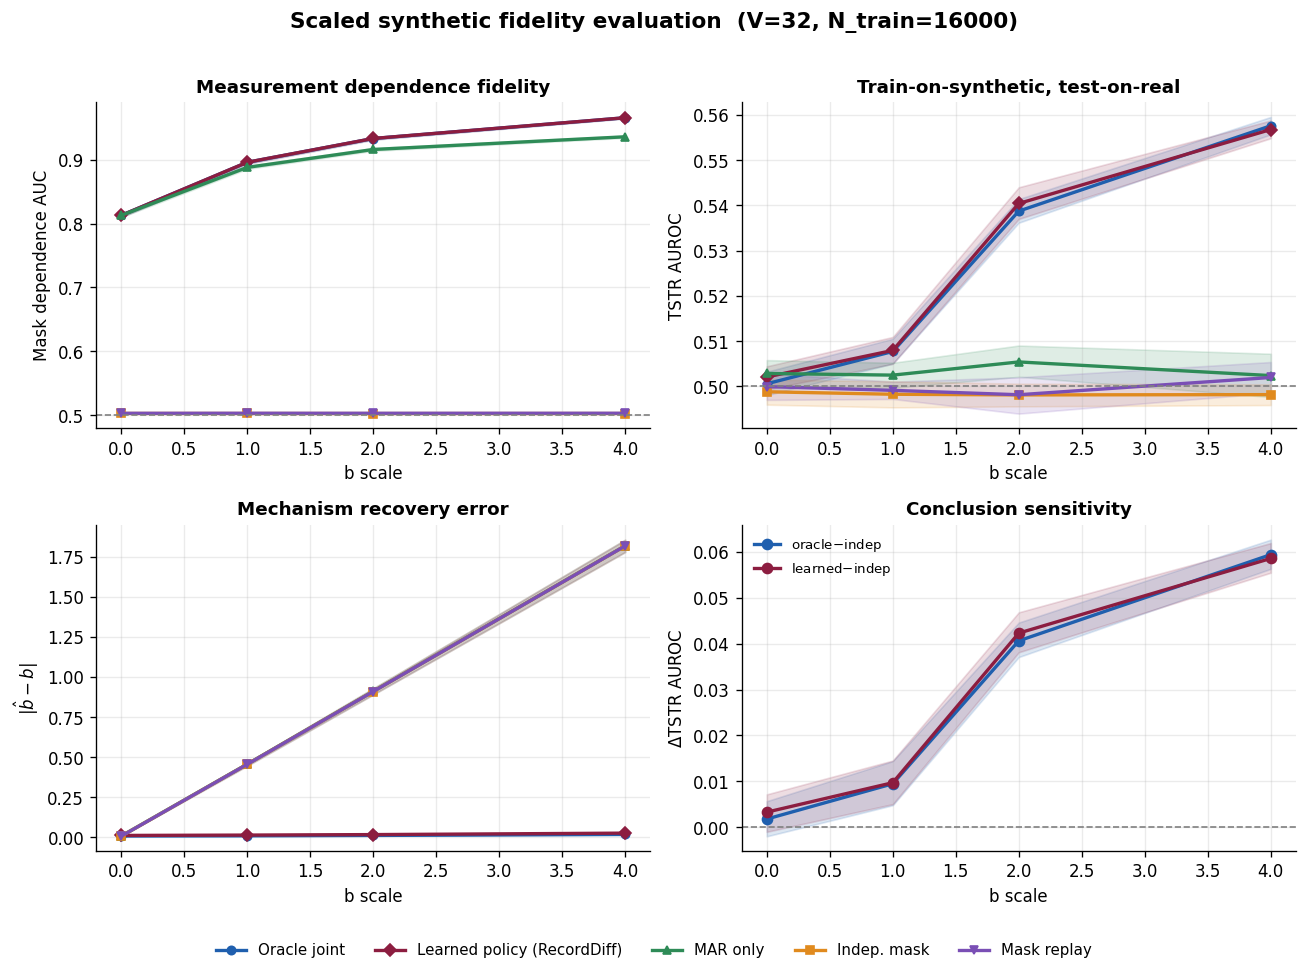

In [ ]:
fig = plot_anchor(anchor_df, ANCHOR_V, ANCHOR_N)
plt.show()

### 5.1 Conclusion-sensitivity tables (FDR-controlled)

In [ ]:
np_perm = 200_000 if PRESET == "FULL" else 50_000
tab_oracle  = sensitivity_table(anchor_df, ref="oracle",  base="independent", n_perm=np_perm)
tab_learned = sensitivity_table(anchor_df, ref="learned", base="independent", n_perm=np_perm)
_pf, _qf = wilcoxon_power_floor(len(SEEDS_ANCHOR), len(B_SWEEP))
print(f"[resolution] {len(SEEDS_ANCHOR)} seeds -> Wilcoxon p-floor={_pf:.4g}, "
      f"best BH-q ~= {_qf:.4g}. q at/near this floor is seed-limited, not effect-limited; "
      f"increase seeds (e.g. FULL) for finer resolution.")
print("=== oracle - independent ===");  display(tab_oracle.round(5))
print("=== learned - independent ==="); display(tab_learned.round(5))

[resolution] 20 seeds -> Wilcoxon p-floor=9.537e-07, best BH-q ~= 3.815e-06. q at/near this floor is seed-limited, not effect-limited; increase seeds (e.g. FULL) for finer resolution.
=== oracle - independent ===


,b_scale,delta,ci_lo,ci_hi,p_wilcoxon,q_wilcoxon_BH,q_signflip_BH
0,0,0.00176,-0.00201,0.00566,0.24900,0.24900,0.19602
1,1,0.00945,0.00478,0.01440,0.00043,0.00057,0.00082
2,2,0.04063,0.03709,0.04461,0.00000,0.00000,0.00002
3,4,0.05942,0.05633,0.06269,0.00000,0.00000,0.00002


=== learned - independent ===


,b_scale,delta,ci_lo,ci_hi,p_wilcoxon,q_wilcoxon_BH,q_signflip_BH
0,0,0.00327,-0.00103,0.00714,0.02422,0.02422,0.07364
1,1,0.00969,0.00501,0.01452,0.00136,0.00181,0.00080
2,2,0.04231,0.03813,0.04685,0.00000,0.00000,0.00002
3,4,0.05859,0.05548,0.06196,0.00000,0.00000,0.00002


## 6. Experiment B: Scaling along records $N$

N-sweep:   0%|          | 0/10 [00:00<?, ?it/s]

[checkpoint] saved 'n_sweep' -> ./n_sweep.pkl


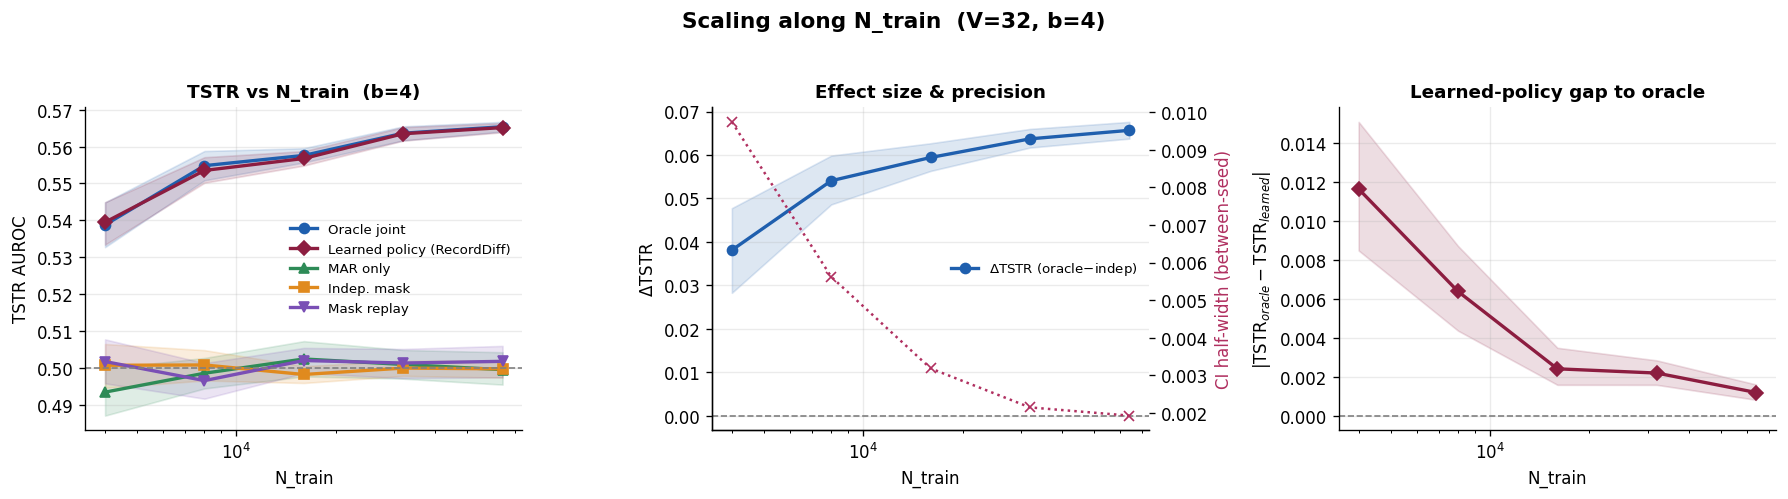

In [ ]:
n_cfgs = [dict(V=ANCHOR_V, N_train=n, b_scale=b) for n in N_GRID for b in [0, 4]]
n_df, n_tim = run_or_load("n_sweep", n_cfgs, SEEDS_SCALE, fit_diag=False, desc="N-sweep")
fig = plot_scaling(n_df, axis="N_train", fixed_label=f"V={ANCHOR_V}, b=4", strong_b=4)
plt.show()

## 7. Experiment C: Scaling along variables $V$

V-sweep:   0%|          | 0/10 [00:00<?, ?it/s]

[checkpoint] saved 'v_sweep' -> ./v_sweep.pkl


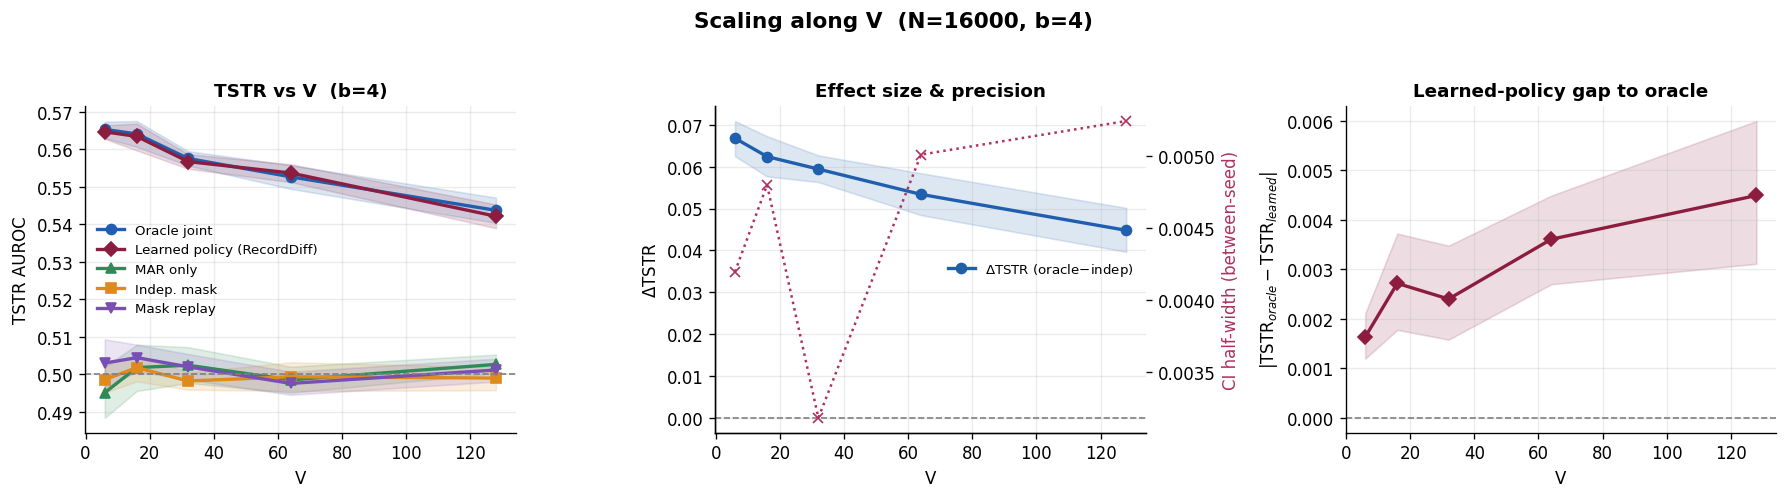

In [ ]:
v_cfgs = [dict(V=v, N_train=ANCHOR_N, b_scale=b) for v in V_GRID for b in [0, 4]]
v_df, v_tim = run_or_load("v_sweep", v_cfgs, SEEDS_SCALE, fit_diag=False, desc="V-sweep")
fig = plot_scaling(v_df, axis="V", fixed_label=f"N={ANCHOR_N}, b=4", strong_b=4)
plt.show()

## 8. Experiment D: Joint $V\times N$ effect-size surface

VxN grid:   0%|          | 0/12 [00:00<?, ?it/s]

[checkpoint] saved 'vxn_grid' -> ./vxn_grid.pkl
marginal effect vs V (avg over N):
    V=  16  mean dTSTR=0.0606
    V=  32  mean dTSTR=0.0632
    V=  64  mean dTSTR=0.0504
    V= 128  mean dTSTR=0.0458
marginal effect vs N (avg over V):
    N=  8000  mean dTSTR=0.0490
    N= 16000  mean dTSTR=0.0570
    N= 32000  mean dTSTR=0.0589


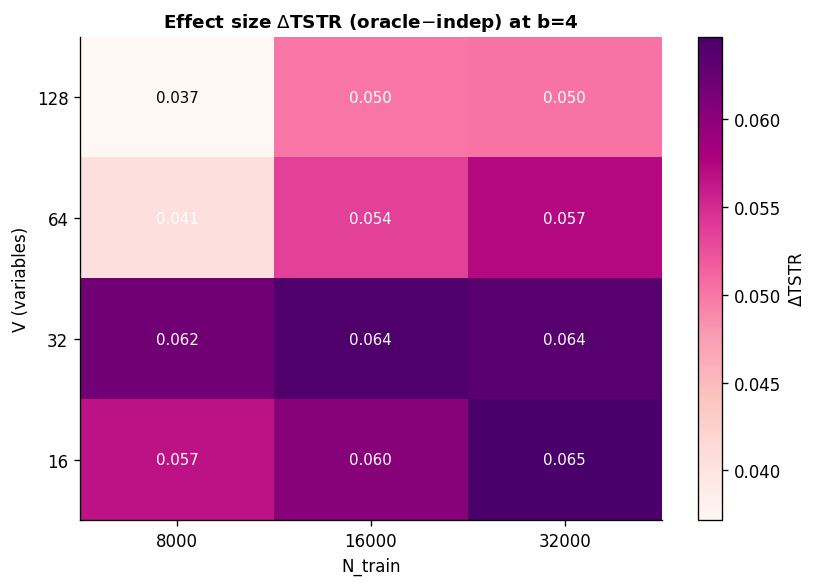

In [ ]:
grid_cfgs = [dict(V=v, N_train=n, b_scale=4) for v in GRID_V for n in GRID_N]
grid_df, grid_tim = run_or_load("vxn_grid", grid_cfgs, SEEDS_GRID, fit_diag=False, desc="VxN grid")
fig = plot_grid_heatmap(grid_df, strong_b=4)
plt.show()

## 9. Computational scaling

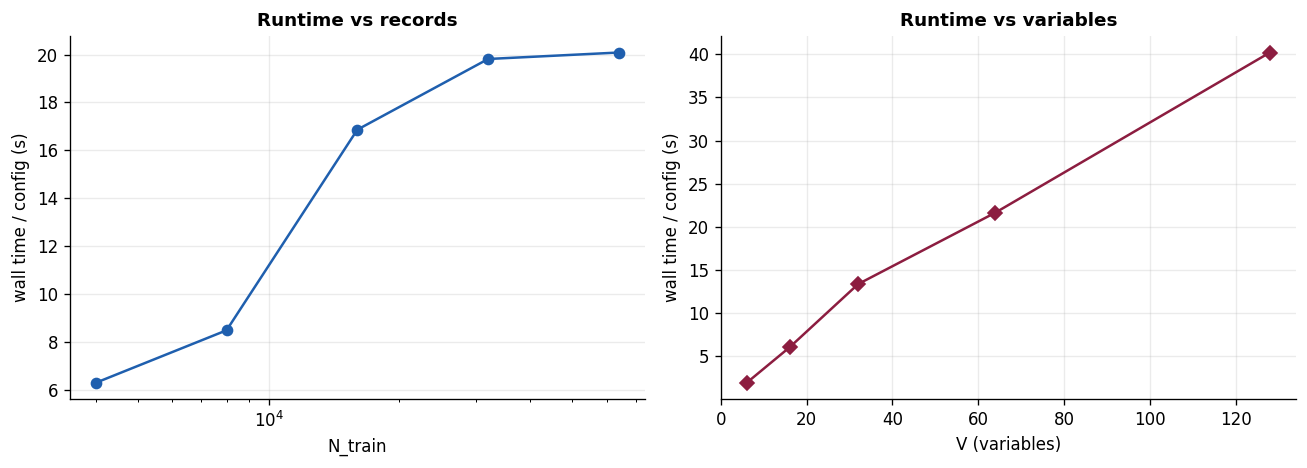

total compute (this session): 150.5 min


In [ ]:
all_tim = pd.concat([anchor_tim, n_tim, v_tim, grid_tim], ignore_index=True)
fig = plot_runtime(all_tim)
plt.show()
print("total compute (this session): %.1f min" % (all_tim.wall_s.sum() / 60))